# 01-The Modern Data Stack & ELT Physics

In the previous sections, we built applications. We engineered agents, orchestrated LangGraphs, and deployed APIs. However, software applications do not exist in a vacuum. They generate massive, continuous streams of data: logs, transactions, LLM traces, and user events.

To capture, process, and analyze this data at an Enterprise scale, we must move out of the Application Layer and into the **Modern Data Stack (MDS)**. We must engineer **Data Pipelines**.

Historically, data engineers used the **ETL** (Extract, Transform, Load) paradigm. Today, due to the physics of cloud computing, the industry has universally shifted to **ELT** (Extract, Load, Transform).

Let's set up our environment to engineer the physical difference between these two architectures.

In [1]:
# Required installations: pip install requests duckdb pandas matplotlib seaborn
import os
import json
import requests
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Data Engineering Environment Ready.")

✅ Systems Architecture & Data Engineering Environment Ready.


# 1. The Physics of Data Gravity (ETL vs. ELT)

### The ETL Bottleneck (Extract $\rightarrow$ Transform $\rightarrow$ Load)

In the 2010s, databases were slow and storage was expensive. Therefore, you could not load raw, messy data into them.
You had to extract the data, pull it into a Python server's RAM, transform it (clean it, aggregate it), and *then* load the finalized data into the warehouse.

Let $V$ be the volume of data in gigabytes, and $M_{server}$ be the RAM of your Python server.
If $V > M_{server}$, the server throws an `OutOfMemoryError` (OOM) and the pipeline catastrophically crashes. Your compute is strictly bottlenecked by the middleman.

### The ELT Paradigm (Extract $\rightarrow$ Load $\rightarrow$ Transform)

In the modern era, Cloud Data Warehouses (Snowflake, BigQuery, Redshift) and local OLAP engines (DuckDB) have effectively infinite, distributed compute.

**Data Gravity** states that data has mass. Moving massive amounts of data across networks into Python scripts is slow and dangerous. Therefore, we should move the *compute* to the *data*, not the *data* to the *compute*.

In ELT:

1. **Extract**: Pull the raw JSON/CSV data.
2. **Load**: Dump the exact, raw, messy JSON directly into the Data Warehouse (The Data Lake landing zone).
3. **Transform**: Execute raw SQL *inside* the Warehouse to transform the data.

Because the transformation happens natively inside the Database's C++ execution engine, $M_{server}$ is no longer a bottleneck. The SQL engine scales automatically to handle terabytes of data.

# 2. Architecting the "E" and "L" (Extract & Load)

Let's build a real, executable ELT pipeline.
We will query a live REST API, extract heavily nested, messy JSON data, and load it directly into a physical DuckDB database file. **We will do zero transformation in Python.**

In [2]:
# --- 🚚 Phase 1: Extract & Load (The "E" and "L") ---

# 1. EXTRACT: Fetch raw, heavily nested JSON data from a public REST API
print("--- 📡 Extracting Data from REST API ---")
api_url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(api_url)
raw_data = response.json()

# Look at how messy the raw payload is (Nested dictionaries for 'address' and 'company')
print(f"Sample Raw Record: {json.dumps(raw_data[0]['address'], indent=2)}")

# Save the raw data to a local JSON file (Simulating an S3 / Data Lake Landing Zone)
landing_zone_file = "raw_landing_users.json"
with open(landing_zone_file, "w") as f:
    json.dump(raw_data, f)
print(f"✅ Extracted {len(raw_data)} records to S3 Landing Zone: '{landing_zone_file}'")


# 2. LOAD: Dump the raw data into the Data Warehouse (DuckDB)
print("\n--- 🗄️ Loading Raw Data into Data Warehouse ---")
# Initialize a physical on-disk database
conn = duckdb.connect('enterprise_warehouse.db')

# We use DuckDB's native JSON reader to load the data exactly as it is.
# We create a 'Bronze' table (Raw Layer)
conn.execute("DROP TABLE IF EXISTS bronze_users;")
conn.execute(f"""
    CREATE TABLE bronze_users AS 
    SELECT * FROM read_json_auto('{landing_zone_file}');
""")

print("✅ Loaded raw data into 'bronze_users' table.")

# Prove the data is in the DB but still heavily nested
bronze_df = conn.execute("SELECT id, name, address FROM bronze_users LIMIT 2").df()
print("\n[Bronze Table State (Notice 'address' is still a nested Struct)]:")
print(bronze_df.to_string())

--- 📡 Extracting Data from REST API ---
Sample Raw Record: {
  "street": "Kulas Light",
  "suite": "Apt. 556",
  "city": "Gwenborough",
  "zipcode": "92998-3874",
  "geo": {
    "lat": "-37.3159",
    "lng": "81.1496"
  }
}
✅ Extracted 10 records to S3 Landing Zone: 'raw_landing_users.json'

--- 🗄️ Loading Raw Data into Data Warehouse ---
✅ Loaded raw data into 'bronze_users' table.

[Bronze Table State (Notice 'address' is still a nested Struct)]:
   id           name                                                                                                                                           address
0   1  Leanne Graham      {'street': 'Kulas Light', 'suite': 'Apt. 556', 'city': 'Gwenborough', 'zipcode': '92998-3874', 'geo': {'lat': '-37.3159', 'lng': '81.1496'}}
1   2   Ervin Howell  {'street': 'Victor Plains', 'suite': 'Suite 879', 'city': 'Wisokyburgh', 'zipcode': '90566-7771', 'geo': {'lat': '-43.9509', 'lng': '-34.4618'}}


# 3. Architecting the "T" (Transforming in SQL)

Now that the data is securely resting inside our high-performance OLAP engine, we perform the **Transform** phase. We write SQL to flatten the JSON, enforce data types, and prepare it for business intelligence dashboards.

This completely bypasses Python's RAM limits.

In [3]:
# --- 🛠️ Phase 2: Transform (The "T" in ELT) ---

print("\n--- ⚙️ Transforming Data IN-DATABASE (Pushdown Compute) ---")

# We execute SQL to unpack the structs and cast types.
# We create a 'Silver' table (Cleaned/Conformed Layer)
transform_query = """
    CREATE OR REPLACE TABLE silver_users AS
    SELECT 
        id::INT AS user_id,
        name::VARCHAR AS full_name,
        email::VARCHAR AS email_address,
        
        -- Unpacking the nested JSON Structs directly in SQL!
        address.city::VARCHAR AS city,
        address.geo.lat::FLOAT AS latitude,
        address.geo.lng::FLOAT AS longitude,
        company.name::VARCHAR AS company_name
        
    FROM bronze_users;
"""

# The database executes the compute, not Python!
conn.execute(transform_query)
print("✅ Transformation complete. Created 'silver_users' table.")

# 4. Verify the Final Analytics-Ready Data
silver_df = conn.execute("SELECT user_id, full_name, city, company_name FROM silver_users LIMIT 5").df()

print("\n[Silver Table State (Flat, Typed, and Analytics-Ready)]:")
print(silver_df.to_string())

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the SQL query. We didn't write Python `for` loops to iterate through dictionaries. We didn't use `pandas.json_normalize()`. We loaded the raw string into DuckDB and used `address.geo.lat::FLOAT` to extract and cast the data at the C++ execution level. If this JSON file was 500GB, doing this in Python would crash your laptop instantly. Doing it in DuckDB/Snowflake would process it in seconds.")


--- ⚙️ Transforming Data IN-DATABASE (Pushdown Compute) ---
✅ Transformation complete. Created 'silver_users' table.

[Silver Table State (Flat, Typed, and Analytics-Ready)]:
   user_id         full_name           city        company_name
0        1     Leanne Graham    Gwenborough     Romaguera-Crona
1        2      Ervin Howell    Wisokyburgh        Deckow-Crist
2        3  Clementine Bauch  McKenziehaven  Romaguera-Jacobson
3        4  Patricia Lebsack    South Elvis       Robel-Corkery
4        5  Chelsey Dietrich     Roscoeview         Keebler LLC

--- 💡 Engineering Insight ---
Look closely at the SQL query. We didn't write Python `for` loops to iterate through dictionaries. We didn't use `pandas.json_normalize()`. We loaded the raw string into DuckDB and used `address.geo.lat::FLOAT` to extract and cast the data at the C++ execution level. If this JSON file was 500GB, doing this in Python would crash your laptop instantly. Doing it in DuckDB/Snowflake would process it in seconds

# 4. Visualizing the Architectural Topography

To scientifically map why ELT destroyed ETL in the Enterprise space, let's visualize the exact physical data flow and the location of the **Compute Bottleneck**.

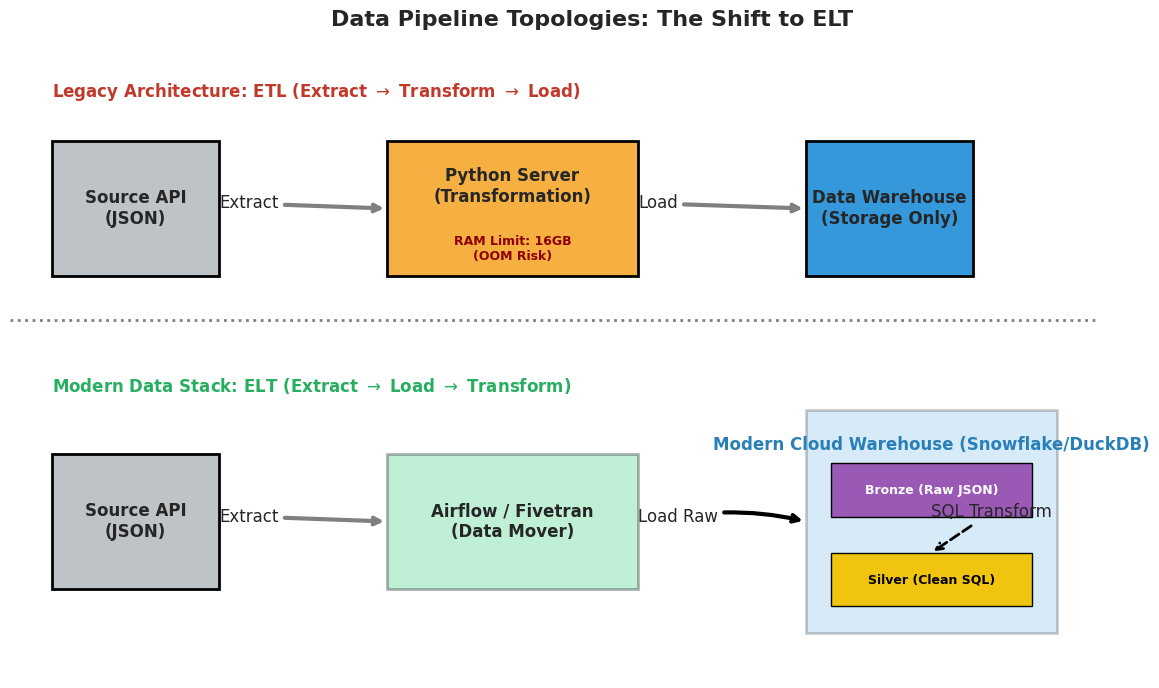

In [4]:
# Visualizing the ETL vs ELT Topography
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Data Pipeline Topologies: The Shift to ELT", fontsize=16, fontweight='bold')

ax.axis('off')

# --- TOP HALF: The Legacy ETL Architecture ---
ax.text(0.5, 6.5, "Legacy Architecture: ETL (Extract $\\rightarrow$ Transform $\\rightarrow$ Load)", fontsize=12, fontweight='bold', color='#c0392b')

# 1. Source System
ax.add_patch(patches.Rectangle((0.5, 4.5), 2, 1.5, fill=True, color='#bdc3c7', ec='black', lw=2))
ax.text(1.5, 5.25, "Source API\n(JSON)", ha='center', va='center', fontweight='bold')

# 2. Python Server (The Bottleneck)
ax.add_patch(patches.Rectangle((4.5, 4.5), 3, 1.5, fill=True, color='#f5b041', ec='black', lw=2))
ax.text(6, 5.5, "Python Server\n(Transformation)", ha='center', va='center', fontweight='bold')
ax.text(6, 4.8, "RAM Limit: 16GB\n(OOM Risk)", ha='center', va='center', fontsize=9, color='darkred', fontweight='bold')

# 3. Data Warehouse
ax.add_patch(patches.Rectangle((9.5, 4.5), 2, 1.5, fill=True, color='#3498db', ec='black', lw=2))
ax.text(10.5, 5.25, "Data Warehouse\n(Storage Only)", ha='center', va='center', fontweight='bold')

# ETL Arrows
ax.annotate("Extract", xy=(4.5, 5.25), xytext=(2.5, 5.25), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))
ax.annotate("Load", xy=(9.5, 5.25), xytext=(7.5, 5.25), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))

# Divider
ax.axhline(y=4, color='black', linestyle=':', linewidth=2, alpha=0.5)

# --- BOTTOM HALF: The Modern ELT Architecture ---
ax.text(0.5, 3.2, "Modern Data Stack: ELT (Extract $\\rightarrow$ Load $\\rightarrow$ Transform)", fontsize=12, fontweight='bold', color='#27ae60')

# 1. Source System
ax.add_patch(patches.Rectangle((0.5, 1), 2, 1.5, fill=True, color='#bdc3c7', ec='black', lw=2))
ax.text(1.5, 1.75, "Source API\n(JSON)", ha='center', va='center', fontweight='bold')

# 2. Extract/Load Orchestrator (No Compute!)
ax.add_patch(patches.Rectangle((4.5, 1), 3, 1.5, fill=True, color='#2ecc71', alpha=0.3, ec='black', lw=2))
ax.text(6, 1.75, "Airflow / Fivetran\n(Data Mover)", ha='center', va='center', fontweight='bold')

# 3. Modern Cloud Warehouse
warehouse_box = patches.Rectangle((9.5, 0.5), 3, 2.5, fill=True, color='#3498db', alpha=0.2, ec='black', lw=2)
ax.add_patch(warehouse_box)
ax.text(11, 2.6, "Modern Cloud Warehouse (Snowflake/DuckDB)", ha='center', va='center', fontweight='bold', color='#2980b9')

# Internal Warehouse Architecture
ax.add_patch(patches.Rectangle((9.8, 1.8), 2.4, 0.6, fill=True, color='#9b59b6', ec='black'))
ax.text(11, 2.1, "Bronze (Raw JSON)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((9.8, 0.8), 2.4, 0.6, fill=True, color='#f1c40f', ec='black'))
ax.text(11, 1.1, "Silver (Clean SQL)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Internal SQL Transformation Arrow
ax.annotate("SQL Transform", xy=(11, 1.4), xytext=(11, 1.8), arrowprops=dict(arrowstyle="->", lw=2, color="black", linestyle="--"))

# ELT Arrows
ax.annotate("Extract", xy=(4.5, 1.75), xytext=(2.5, 1.75), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))
ax.annotate("Load Raw", xy=(9.5, 1.75), xytext=(7.5, 1.75), arrowprops=dict(arrowstyle="->", lw=3, color="black", connectionstyle="arc3,rad=-0.1"))

plt.xlim(0, 13)
plt.ylim(0, 7)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the shift from ETL to ELT like **The Global Supply Chain of Crude Oil**:

* **ETL (Refining at the Drill Site)**: You strike oil in the middle of the ocean. In the ETL paradigm, you build a massive, multi-billion-dollar chemical refinery on top of the tiny oil rig. You pump the crude oil, refine it into gasoline right there, and then ship the finished gasoline to the mainland. This is terribly inefficient. The rig (your Python server) is too small to handle massive chemical processing (Transformations). It bottlenecks the entire operation.
* **ELT (Refining at the Destination)**: You strike oil. You immediately pump the raw, messy crude oil directly into giant shipping tankers (Extract and Load). You sail the crude oil to the mainland, dump it into massive coastal mega-refineries, and process it there (Transform). The mega-refinery (Snowflake, BigQuery, DuckDB) has infinite physical space and dedicated processing power.

By separating the movement of data from the transformation of data, Data Engineers can ingest petabytes of information without ever worrying about a Python script crashing due to memory limits.